In [1]:
import numpy as np
import matplotlib.pyplot as plt
import OptimalBattery.util as ut
from Functional_Fusion.dataset import DataSetMDTB
import os
import pickle
import Functional_Fusion.atlas_map as am
from IndividualParcellation.global_config import *
import OptimalBattery.evaluate as ev
import PcmPy as pcm
import seaborn as sns
import nilearn.plotting as plotting
from scipy.stats import spearmanr,pearsonr
import nitools as nt
import pandas as pd


Default device set to: cuda


# define atlas for data used and ROI mask dir

In [2]:
space = 'fs32k'
atlas,_= am.get_atlas(atlas_str=space)
base_dir = 'Y:/data/FunctionalFusion/'
if not os.path.exists(base_dir):
    base_dir = '/cifs/diedrichsen/data/FunctionalFusion/'
cort_dir = 'Y:/data/Atlas_templates/fs_LR_32'

# Get Vs for mdtb_1 and mdtb_2 from nettekoven 32

In [3]:
model_dir = 'Y:/data/Cerebellum/ProbabilisticParcellationModel/Models/Models_03/NettekovenSym32_space-MNISymC2_D5.pickle'
with open(model_dir, 'rb') as f:
    full_model = pickle.load(f)[0]

# load emission model & Vs for mdtb ses-1
mdtb_1_emission = full_model.emissions[0]
mdtb_1_Vs = mdtb_1_emission.V
VL_mdtb_1 = mdtb_1_Vs.cpu().numpy()
VL_mdtb_1 = VL_mdtb_1[:28,:]

mdtb_2_emission = full_model.emissions[1]
mdtb_2_Vs = mdtb_2_emission.V
VL_mdtb_2 = mdtb_2_Vs.cpu().numpy()


In [4]:
lut_file_dir = 'Y:/data/Cerebellum/ProbabilisticParcellationModel/Atlases/NettekovenSym32.lut'
lut = pd.read_csv(lut_file_dir, sep=' ', header=None)
# ge the parcel names from the 4th column
parcel_names = lut.iloc[:,4].values
parcel_names = parcel_names[1:]
len(parcel_names)

32

# Make ROI

In [5]:
  # Load surface files for left and right hemispheres
surfs = [f"{base_dir}/Atlases/tpl-fs32k/tpl-fs32k_hemi-{h}_inflated.surf.gii" for h in ['L', 'R']]
def plot_cortex(data, threshold=0.0, cmap='binary', figsize=(12, 6)):  

    # Convert data to CIFTI format
    cifti = atlas.data_to_cifti(data)
    
    # Extract data for the cortical surfaces
    all_img = nt.surf_from_cifti(cifti)
    
    # Create the plot
    fig, axes = plt.subplots(1, 2, subplot_kw={'projection': '3d'}, figsize=figsize)
    for h, hemi in enumerate(['left', 'right']):
        plotting.plot_surf_stat_map(
            surfs[h], all_img[h], hemi=hemi,
            colorbar=False,
            cmap=cmap,
            axes=axes[h],
            threshold=threshold,
            title=f'figure {h+1}'
        )
    
    return fig


In [ ]:
# roi (prefrontal cortex)
ROI_cortex = [1]
atlas_dir = f'{base_dir}/Atlases/tpl-fs32k'
model_name_L = f'{atlas_dir}/HumanLobes.L.label.gii'
model_name_R = f'{atlas_dir}/HumanLobes.R.label.gii'

yeo_parcels = atlas.read_data([model_name_L,model_name_R])
ROI_mask = np.isin(yeo_parcels, ROI_cortex).astype(int)


mask_reshaped = ROI_mask[np.newaxis, :]  # Reshape to (1, 59518)

fig = plot_cortex(mask_reshaped, threshold=0.1, cmap='binary', figsize=(12, 6))
plt.show()

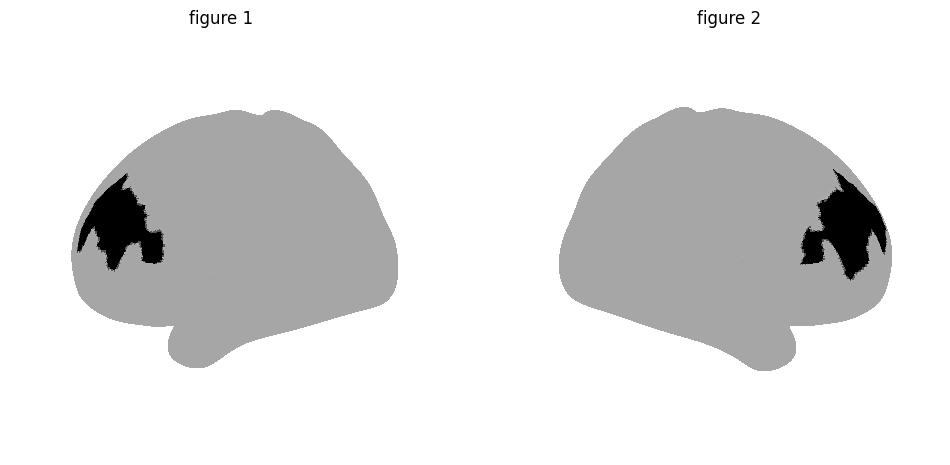

In [28]:
# roi (prefrontal cortex)
ROI_cortex = [74,81,82,83,84,86]
atlas_dir = f'{base_dir}/Atlases/tpl-fs32k'
model_name_L = f'{atlas_dir}/glasser.L.label.gii'
model_name_R = f'{atlas_dir}/glasser.R.label.gii'

yeo_parcels = atlas.read_data([model_name_L,model_name_R])
ROI_mask = np.isin(yeo_parcels, ROI_cortex).astype(int)


mask_reshaped = ROI_mask[np.newaxis, :]  # Reshape to (1, 59518)

fig = plot_cortex(mask_reshaped, threshold=0.1, cmap='binary', figsize=(12, 6))
plt.show()


# get indices of voxels in ROI for evaluation later

In [29]:
# find indices where mask is 1 
ROI_indices = np.where(ROI_mask == 1)[0]
len(ROI_indices)

2116

# Load data

In [8]:
MDTB_dataset = DataSetMDTB('/cifs/diedrichsen/data/FunctionalFusion/MDTB')
if not os.path.exists('/cifs/diedrichsen/data/FunctionalFusion/MDTB'):
    MDTB_dataset = DataSetMDTB('Y:/data/FunctionalFusion/MDTB')

data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondRun')
data_mdtb_s1_run[np.isnan(data_mdtb_s1_run)] = 0
data_mdtb_s1_run = data_mdtb_s1_run[:,:,:]


data_mdtb_s1_all,info_mdtb_1_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondAll')
data_mdtb_s1_all[np.isnan(data_mdtb_s1_all)] = 0
data_mdtb_s1_all = data_mdtb_s1_all[:,:,:]



data_mdtb_s2_all,info_mdtb_2_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s2',type='CondAll')
data_mdtb_s2_all[np.isnan(data_mdtb_s2_all)] = 0


In [9]:
data_mdtb_s1_run,info_mdtb_1_run = ut.recenter_fmri_data(data_mdtb_s1_run,info_mdtb_1_run,task_column_name='cond_name',center_condition='rest')
print(data_mdtb_s1_run.shape)

data_mdtb_s1_all,info_mdtb_1_all = ut.recenter_fmri_data(data_mdtb_s1_all,info_mdtb_1_all,task_column_name='cond_name',center_condition='rest')
print(data_mdtb_s1_all.shape)

(24, 448, 59518)
(24, 28, 59518)


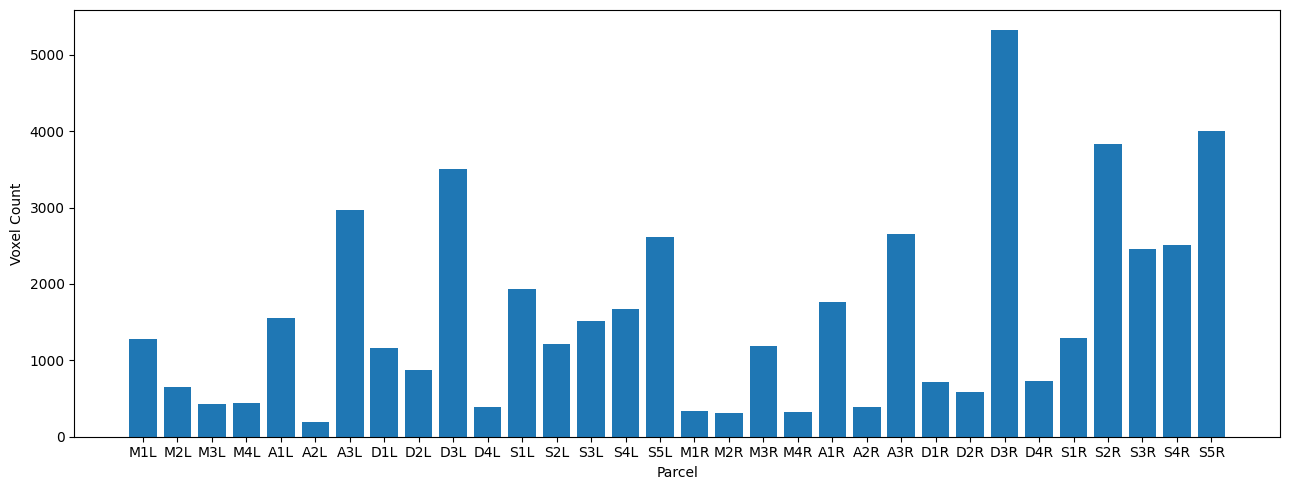

array([25, 31, 28,  9,  6, 22, 15, 30], dtype=int64)

In [30]:
# get top 4 parcels with highest voxel counts within ROI
total_parcel_counts = np.zeros(32)

for subject_data in data_mdtb_s1_all:
    data = subject_data[:, ROI_indices]
    
    data_projected = VL_mdtb_1.T @ data
    data_projected_onehot = ev.get_U_hat_one_hot(data_projected)[0]
    
    total_parcel_counts += np.sum(data_projected_onehot, axis=1)

plt.figure(figsize=(13, 5))
plt.bar(range(1, 33), total_parcel_counts, tick_label=parcel_names)
plt.xlabel('Parcel')
plt.ylabel('Voxel Count')
plt.tight_layout()
plt.show()

# choose 4 parcels with top voxel counts
top_parcels = np.argsort(total_parcel_counts)[::-1][:8]
top_parcels



# subset VLib and Vtest to only include parcels with most voxels in ROI

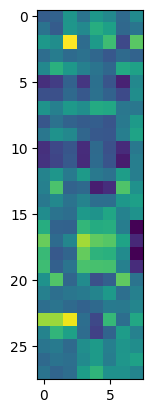

In [31]:
VLib = VL_mdtb_1[:,top_parcels]
plt.imshow(VLib)

In [32]:
vtest =  VL_mdtb_2[:,top_parcels]
vtest.shape

(32, 8)

# Get crossvalidated second moment matrix (GLib)

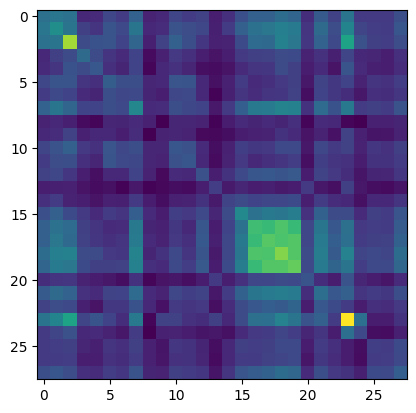

In [33]:
cond_vec = np.tile(np.arange(1, 28 + 1), 16)
part_vec = np.repeat(np.arange(1, 16 + 1), 28)
Gs_list = []
E_list = []
for i in range(data_mdtb_s1_run.shape[0]):
    Gs,E = pcm.util.est_G_crossval(data_mdtb_s1_run[i][:,ROI_indices] , cond_vec, part_vec)
    Gs_list.append(Gs)
    E_list.append(E)

Gs_list = np.stack(Gs_list, 0)
G_Lib = np.mean(Gs_list, axis=0)

plt.imshow(G_Lib)

In [34]:
D = ut.build_combinations(G_Lib, strategy='random',n_iter=500,n_tasks=8,seed=1,replacement=True)
D_ev = ev.evaluate_dataframe_real_multiregion(D, data_mdtb_s1_all,VLib,data_mdtb_s2_all, vtest,ROI_indices)
D_ev = D_ev.reset_index(drop=True)


Processing combination: 0
Processing combination: 10
Processing combination: 20
Processing combination: 30
Processing combination: 40
Processing combination: 50
Processing combination: 60
Processing combination: 70
Processing combination: 80
Processing combination: 90
Processing combination: 100
Processing combination: 110
Processing combination: 120
Processing combination: 130
Processing combination: 140
Processing combination: 150
Processing combination: 160
Processing combination: 170
Processing combination: 180
Processing combination: 190
Processing combination: 200
Processing combination: 210
Processing combination: 220
Processing combination: 230
Processing combination: 240
Processing combination: 250
Processing combination: 260
Processing combination: 270
Processing combination: 280
Processing combination: 290
Processing combination: 300
Processing combination: 310
Processing combination: 320
Processing combination: 330
Processing combination: 340
Processing combination: 350
Pro

In [35]:
# find the index of the lowest log_det_mc value
min_log_det_mc_idx = D_ev['log_det_mc'].idxmax()

# get the combination tuple
min_log_det_mc_comb =list( D_ev.loc[min_log_det_mc_idx, 'combination'])

battery = ut.translate_battery(info_mdtb_1_all, min_log_det_mc_comb)
battery


array(['NoGo', 'ToM', 'VideoAct', 'VideoKnots', 'SadFaces', 'Verbal0Back',
       'SpatialNavigation', 'VerbGen'], dtype=object)

In [15]:
num_batteries = 500
num_iterations = 10000
eval_metric = 'cos'
output_df = ut.max_value_distribution_analysis(D_ev, num_batteries, num_iterations, eval_metric)

In [16]:
# only inlucde these columns
criteria = ["variance", "variance_mc"]
output_df_sub = output_df[criteria]


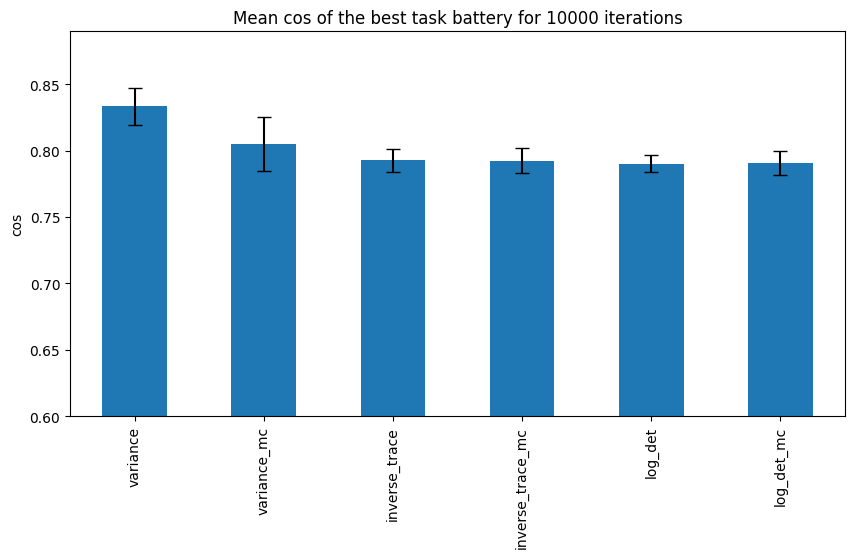

In [17]:
# plot the means as a bar plot
fig, ax = plt.subplots(figsize=(10, 5))
output_df.mean().plot(kind='bar', ax=ax, yerr=output_df.std(), capsize=5)


ax.set_ylim(bottom=0.6)
ax.set_ylabel(eval_metric)
ax.set_title(f'Mean {eval_metric} of the best task battery for {num_iterations} iterations')
plt.show()

# n_task?

In [18]:
battery_sizes = [4,6,8,10,14,18,22]

In [19]:
results_list = []

for i in battery_sizes:
    print(f"Processing battery size: {i}")
    
    # Generate task combinations and evaluate
    D = ut.build_combinations(G_Lib, strategy='random',n_iter=1000,n_tasks=i,seed=1,replacement=True)
    D_ev = ev.evaluate_dataframe_real_multiregion(D, data_mdtb_s1_all,VLib,data_mdtb_s2_all, vtest,ROI_indices)
    D_ev = D_ev.reset_index(drop=True)
    
    # Perform max value distribution analysis
    num_batteries = 500
    num_iterations = 1000
    eval_metric = 'cos'
    output_df = ut.max_value_distribution_analysis(D_ev, num_batteries, num_iterations, eval_metric)
    output_long = output_df.melt(var_name="metric", value_name="value")
    
    output_long["battery_size"] = i
    
    results_list.append(output_long)

results_df_task = pd.concat(results_list, ignore_index=True)

Processing battery size: 4
Processing combination: 0
Processing combination: 10
Processing combination: 20
Processing combination: 30
Processing combination: 40
Processing combination: 50
Processing combination: 60
Processing combination: 70
Processing combination: 80
Processing combination: 90
Processing combination: 100
Processing combination: 110
Processing combination: 120
Processing combination: 130
Processing combination: 140
Processing combination: 150
Processing combination: 160
Processing combination: 170
Processing combination: 180
Processing combination: 190
Processing combination: 200
Processing combination: 210
Processing combination: 220
Processing combination: 230
Processing combination: 240
Processing combination: 250
Processing combination: 260
Processing combination: 270
Processing combination: 280
Processing combination: 290
Processing combination: 300
Processing combination: 310
Processing combination: 320
Processing combination: 330
Processing combination: 340
Proc

In [20]:
# save
results_df_task.to_csv('C:/Users/barafat/Documents/GitHub/OptimalBattery/dataframes/results_df_task_cortex_frontal_8parcel.csv', index=False)

In [26]:
# only include rows that have metric == 'variance' and 'variance_mc'
criteria = ["variance", "variance_mc","log_det_mc"]
# criteria = ['variance','log_det','inverse_trace','variance_mc','log_det_mc','inverse_trace_mc']
results_df_task_sub = results_df_task[results_df_task["metric"].isin(criteria)]

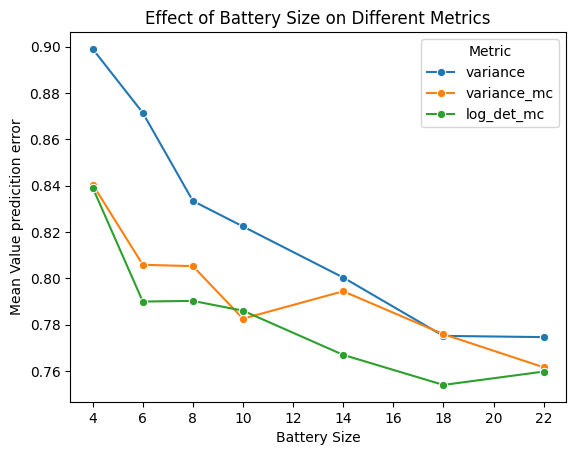

In [27]:
palette = sns.color_palette("tab10", n_colors=len(criteria))

sns.lineplot(
    data=results_df_task_sub,
    x="battery_size",
    y="value",
    hue="metric",
    marker="o",
    palette=palette,
    errorbar=None
)

plt.xlabel("Battery Size")
plt.ylabel("Mean Value predicition error")
plt.title("Effect of Battery Size on Different Metrics")
plt.legend(title="Metric")
# make  the ticks on x increments of 2
plt.xticks(np.arange(4, 23, 2))
plt.show()

# N regions (K)?

In [ ]:
n_parcel = [2,3,4,5,6,7,8,10,12]


In [60]:
results_list = []

total_parcel_counts = np.zeros(32)
for subject_data in data_mdtb_s1_all:
        data = subject_data[:, ROI_indices]
        
        data_projected = VL_mdtb_1.T @ data
        data_projected_onehot = ev.get_U_hat_one_hot(data_projected)[0]
        
        total_parcel_counts += np.sum(data_projected_onehot, axis=1)


for i in n_parcel:
    print(f"Processing n_parcel: {i}")
    
    # choose top n parcels with highest voxel counts
    top_parcels = np.argsort(total_parcel_counts)[::-1][:i]
    VLib = VL_mdtb_1[:,top_parcels]
    vtest =  VL_mdtb_2[:,top_parcels]
    D = ut.build_combinations(G_Lib, strategy='random',n_iter=5000,n_tasks=8,seed=1,replacement=True)
    D_ev = ev.evaluate_dataframe_real_multiregion(D, data_mdtb_s1_all,VLib,data_mdtb_s2_all, vtest,ROI_indices)
    D_ev = D_ev.reset_index(drop=True)

    num_batteries = 500
    num_iterations = 1000
    eval_metric = 'cos'
    output_df = ut.max_value_distribution_analysis(D_ev, num_batteries, num_iterations, eval_metric)

    output_long = output_df.melt(var_name="metric", value_name="value")
    output_long["n_parcel"] = i

    results_list.append(output_long)

results_df_parcel = pd.concat(results_list, ignore_index=True)



    

Processing n_parcel: 2
Processing combination: 0
Processing combination: 10
Processing combination: 20
Processing combination: 30
Processing combination: 40
Processing combination: 50
Processing combination: 60
Processing combination: 70
Processing combination: 80
Processing combination: 90
Processing combination: 100
Processing combination: 110
Processing combination: 120
Processing combination: 130
Processing combination: 140
Processing combination: 150
Processing combination: 160
Processing combination: 170
Processing combination: 180
Processing combination: 190
Processing combination: 200
Processing combination: 210
Processing combination: 220
Processing combination: 230
Processing combination: 240
Processing combination: 250
Processing combination: 260
Processing combination: 270
Processing combination: 280
Processing combination: 290
Iteration 0 of 1000...
Iteration 100 of 1000...
Iteration 200 of 1000...
Iteration 300 of 1000...
Iteration 400 of 1000...
Iteration 500 of 1000...


In [ ]:
# only include rows that have metric == 'variance' and 'variance_mc'
criteria = ["variance", "variance_mc"]
results_df_parcel_sub = results_df_parcel[results_df_parcel["metric"].isin(criteria)]

In [ ]:
palette = sns.color_palette("tab10", n_colors=len(criteria))

sns.lineplot(
    data=results_df_parcel_sub,
    x="n_parcel",
    y="value",
    hue="metric",
    marker="o",
    palette=palette,
    errorbar="sd" 
)

plt.xlabel("Number of Parcels")
plt.ylabel("Mean Value Predicition Error")
plt.title("Effect of Number of Parcels on Different Metrics")
plt.legend(title="Metric")
plt.show()